# 02 - Reinforcement Learning - Evolving MLP [![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RobertTLange/evosax/blob/main/examples/02_rl.ipynb)

## Installation

You will need Python 3.10 or later, and a working JAX installation. For example, you can install JAX on NVIDIA GPU with:

In [ ]:
%pip install -U "jax[cuda]"

Then, install `evosax` from PyPi:

In [ ]:
%pip install -U "evosax[examples]"

## Import

In [1]:
import jax
import matplotlib.pyplot as plt
import optax

In [2]:
seed = 0
key = jax.random.key(seed)

## Gymnax

### CartPole environment

In [11]:
from evosax.problems import GymnaxProblem as Problem
from evosax.problems.networks import MLP, categorical_output_fn

policy = MLP(
    layer_sizes=(64, 64, 2),
    output_fn=categorical_output_fn,
)

problem = Problem(
    env_name="CartPole-v1",
    policy=policy,
    episode_length=200,
    num_rollouts=16,
    use_normalize_obs=True,
)

key, subkey = jax.random.split(key)
problem_state = problem.init(key)

key, subkey = jax.random.split(key)
solution = problem.sample(subkey)

In [12]:
print(f"Number of pararmeters: {sum(leaf.size for leaf in jax.tree.leaves(solution))}")

Number of pararmeters: 4610


### SNES

In [67]:
from evosax.algorithms import SNES as ES

num_generations = 50
population_size = 128

es = ES(
    population_size=population_size,
    solution=solution,
    optimizer=optax.adam(learning_rate=0.01),
)

params = es.default_params

### Run

In [68]:
def step(carry, key):
    state, params, problem_state = carry
    key_ask, key_eval, key_tell = jax.random.split(key, 3)

    population, state = es.ask(key_ask, state, params)

    fitness, problem_state, _ = problem.eval(key_eval, population, problem_state)

    state, metrics = es.tell(
        key_tell, population, -fitness, state, params
    )  # Minimize fitness

    return (state, params, problem_state), metrics

In [69]:
key, subkey = jax.random.split(key)
state = es.init(subkey, solution, params)

key, subkey = jax.random.split(key)
keys = jax.random.split(subkey, num_generations)
(state, params, problem_state), metrics = jax.lax.scan(
    step,
    (state, params, problem_state),
    keys,
)



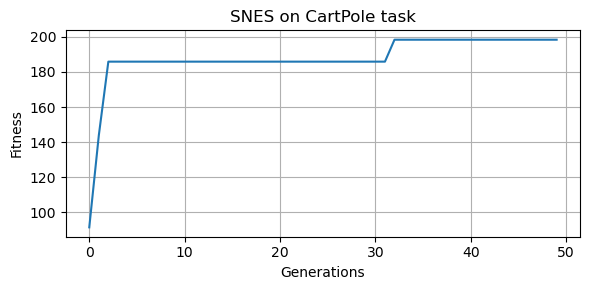

In [70]:
plt.figure(figsize=(6, 3))
plt.plot(-metrics["best_fitness"])

plt.title("SNES on CartPole task")
plt.xlabel("Generations")
plt.ylabel("Fitness")

plt.grid(True)
plt.tight_layout()

plt.show()

In [57]:
mean_solution = es.get_mean(state)
fitness, _, info = problem.eval(key,
                                jax.tree.map(lambda x: x[None], mean_solution),
                                problem_state)

In [59]:
rollout = [
    jax.tree_util.tree_map(lambda x: x[0, 0, t], info["env_states"][1])
    for t in range(problem.episode_length)
]



In [71]:
fitness

Array([42.5], dtype=float32)

MovieWriter ffmpeg unavailable; using Pillow instead.


IndexError: list index out of range

Error in callback <function _draw_all_if_interactive at 0x7fb2cf7bc540> (for post_execute), with arguments args (),kwargs {}:


TypeError: Wrapper.render() got an unexpected keyword argument 'mode'

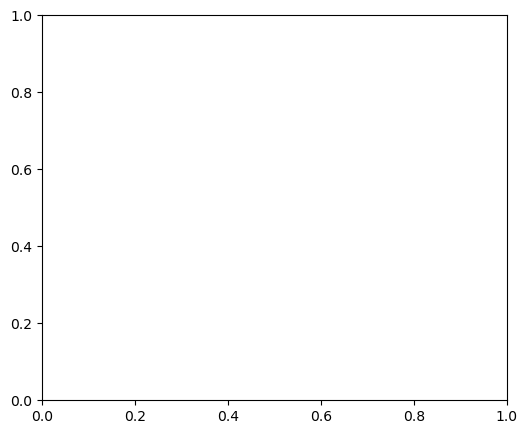

In [61]:
# from gymnax.visualize import Visualizer

# state_seq, reward_seq = [], []
# key, key_reset = jax.random.split(key)
# obs, env_state = env.reset(key_reset, env_params)
# while True:
#     state_seq.append(env_state)
#     key, key_act, key_step = jax.random.split(key, 3)
#     action = env.action_space(env_params).sample(key_act)
#     next_obs, next_env_state, reward, done, info = env.step(
#         key_step, env_state, action, env_params
#     )
#     reward_seq.append(reward)
#     if done:
#         break
#     else:
#       obs = next_obs
#       env_state = next_env_state

cum_rewards = jnp.cumsum(jnp.array([150]*500))
vis = Visualizer(problem.env, problem.env_params, rollout, cum_rewards)
vis.animate(f"nim.gif")


## Brax

### Ant environment

In [3]:
from evosax.problems import BraxProblem as Problem
from evosax.problems.networks import MLP, tanh_output_fn

policy = MLP(
    layer_sizes=(32, 32, 32, 32, 8),
    output_fn=tanh_output_fn,
)

problem = Problem(
    env_name="ant",
    policy=policy,
    episode_length=1000,
    num_rollouts=16,
    use_normalize_obs=True,
)

key, subkey = jax.random.split(key)
problem_state = problem.init(key)

key, subkey = jax.random.split(key)
solution = problem.sample(subkey)

In [4]:
print(f"Number of pararmeters: {sum(leaf.size for leaf in jax.tree.leaves(solution))}")

Number of pararmeters: 4328


### Open_ES

In [5]:
from evosax.algorithms import Open_ES as ES

num_generations = 10
population_size = 256

lr_schedule = optax.exponential_decay(
    init_value=0.01,
    transition_steps=num_generations,
    decay_rate=0.1,
)
std_schedule = optax.exponential_decay(
    init_value=0.05,
    transition_steps=num_generations,
    decay_rate=0.2,
)
es = ES(
    population_size=population_size,
    solution=solution,
    optimizer=optax.adam(learning_rate=lr_schedule),
    std_schedule=std_schedule,
)

params = es.default_params

### Run

In [6]:
def step(carry, key):
    state, params, problem_state = carry
    key_ask, key_eval, key_tell = jax.random.split(key, 3)

    population, state = es.ask(key_ask, state, params)

    fitness, problem_state, _ = problem.eval(key_eval, population, problem_state)

    state, metrics = es.tell(
        key_tell, population, -fitness, state, params
    )  # Minimize fitness

    return (state, params, problem_state), metrics

In [7]:
key, subkey = jax.random.split(key)
state = es.init(subkey, solution, params)

fitness_log = []
log_period = 2
for i in range(num_generations // log_period):
    # Train
    print("Ds")
    key, subkey = jax.random.split(key)
    keys = jax.random.split(subkey, log_period)
    (state, params, problem_state), metrics = jax.lax.scan(
        step,
        (state, params, problem_state),
        keys,
    )
    print("dsa")

    # Eval
    mean = es.get_mean(state)
    key, subkey = jax.random.split(key)
    fitness, problem_state, info = problem.eval(
        key, jax.tree.map(lambda x: x[None], mean), problem_state
    )
    print(f"Generation {(i + 1) * log_period:3d} | Mean fitness: {fitness.mean():.2f}")

Ds
dsa
Generation   2 | Mean fitness: 783.06
Ds
dsa
Generation   4 | Mean fitness: 863.45
Ds


KeyboardInterrupt: 

## Visualize policy

In [8]:
mean = es.get_mean(state)
mean = es._unravel_solution(state.best_solution)

key, subkey = jax.random.split(key)
fitness, problem_state, info = problem.eval(
    key, jax.tree.map(lambda x: x[None], mean), problem_state
)
fitness[0]

Array(898.937, dtype=float32)

In [10]:
from brax.io import html
from IPython.display import HTML

rollout = [
    jax.tree_util.tree_map(lambda x: x[0, 0, t], info["env_states"].pipeline_state)
    for t in range(problem.episode_length)
]

html_content = html.render(
    problem.env.sys.tree_replace({"opt.timestep": problem.env.dt}), rollout
)
HTML(html_content)

# Write to file
with open("ant_visualization.html", "w") as f:
    f.write(html_content)

print("Visualization saved to 'ant_visualization.html'")

Visualization saved to 'ant_visualization.html'


Visualization saved to 'ant_visualization.html'


In [19]:
import jax
import gymnax

key = jax.random.key(0)
key, key_reset, key_act, key_step = jax.random.split(key, 4)

# Instantiate the environment & its settings.
env, env_params = gymnax.make("CartPole-v1")

# Reset the environment.
obs, state = env.reset(key_reset, env_params)

# Sample a random action.
action = env.action_space(env_params).sample(key_act)

# Perform the step transition.
n_obs, n_state, reward, done, _ = env.step(key_step, state, action, env_params)


/home/ronedr/.local/lib/python3.11/site-packages/jax/_src/numpy/array_methods.py:122: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


MovieWriter ffmpeg unavailable; using Pillow instead.


IndexError: list index out of range

Error in callback <function _draw_all_if_interactive at 0x7fb2cf7bc540> (for post_execute), with arguments args (),kwargs {}:


TypeError: Wrapper.render() got an unexpected keyword argument 'mode'

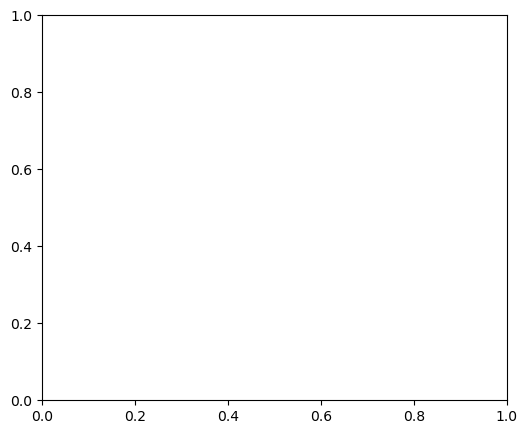

In [22]:
from gymnax.visualize import Visualizer
import jax.numpy as jnp

state_seq, reward_seq = [], []
key, key_reset = jax.random.split(key)
obs, env_state = env.reset(key_reset, env_params)
while True:
    state_seq.append(env_state)
    key, key_act, key_step = jax.random.split(key, 3)
    action = env.action_space(env_params).sample(key_act)
    next_obs, next_env_state, reward, done, info = env.step(
        key_step, env_state, action, env_params
    )
    reward_seq.append(reward)
    if done:
        break
    else:
      obs = next_obs
      env_state = next_env_state

cum_rewards = jnp.cumsum(jnp.array(reward_seq))
vis = Visualizer(env, env_params, state_seq, cum_rewards)
vis.animate(f"anim.gif")
